<a href="https://colab.research.google.com/github/kunalv2002/Bitcoin-Market-Sentiment-Analysis-Assignment/blob/main/Trader_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving fear_greed_index.csv to fear_greed_index.csv
Saving historical_data.csv to historical_data.csv


In [ ]:
import os

print("Uploaded files:")
print(os.listdir())

Uploaded files:
['.config', 'historical_data.csv', 'fear_greed_index.csv', 'sample_data']


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [ ]:
import os
print(os.listdir())

['.config', 'historical_data.csv', 'fear_greed_index.csv', 'sample_data']


In [ ]:
import pandas as pd

trades = pd.read_csv('historical_data.csv')
sentiment = pd.read_csv('fear_greed_index.csv')

print(trades.head())
print(sentiment.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

In [ ]:
print(trades.columns)
print(sentiment.columns)
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)

trades['date'] = trades['Timestamp IST'].dt.date

sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [ ]:
df = trades.merge(
    sentiment[['date', 'classification', 'value']],
    on='date',
    how='left'
)

df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0


In [ ]:
print(df[['date', 'classification', 'value']].head())
print(df['classification'].isnull().sum())

         date classification  value
0  2024-12-02  Extreme Greed   80.0
1  2024-12-02  Extreme Greed   80.0
2  2024-12-02  Extreme Greed   80.0
3  2024-12-02  Extreme Greed   80.0
4  2024-12-02  Extreme Greed   80.0
6


missing values check

In [ ]:
print(df['classification'].isnull().sum())

6


In [ ]:
df = df.dropna(subset=['classification'])
print(df['classification'].isnull().sum())

0


In [ ]:
profit_by_sentiment = df.groupby('classification')['Closed PnL'].agg(
    ['count', 'mean', 'sum', 'median']
)
print(profit_by_sentiment)

                count       mean           sum  median
classification                                        
Extreme Fear    21400  34.537862  7.391102e+05     0.0
Extreme Greed   39992  67.892861  2.715171e+06     0.0
Fear            61837  54.290400  3.357155e+06     0.0
Greed           50303  42.743559  2.150129e+06     0.0
Neutral         37686  34.307718  1.292921e+06     0.0


In [ ]:
df['win'] = df['Closed PnL'] > 0

win_rate = (
    df.groupby('classification')['win']
      .mean()
      .mul(100)
)

print(win_rate)

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: win, dtype: float64


In [ ]:
total_profit = df.groupby('classification')['Closed PnL'].sum()
print(total_profit)

classification
Extreme Fear     7.391102e+05
Extreme Greed    2.715171e+06
Fear             3.357155e+06
Greed            2.150129e+06
Neutral          1.292921e+06
Name: Closed PnL, dtype: float64


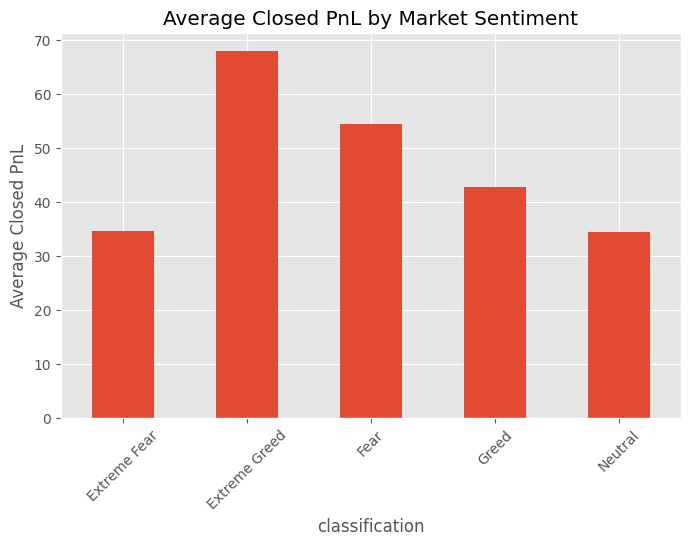

In [ ]:
import matplotlib.pyplot as plt

# Average PnL
avg_pnl = df.groupby('classification')['Closed PnL'].mean()

plt.figure(figsize=(8,5))
avg_pnl.plot(kind='bar')
plt.title('Average Closed PnL by Market Sentiment')
plt.ylabel('Average Closed PnL')
plt.xticks(rotation=45)
plt.show()

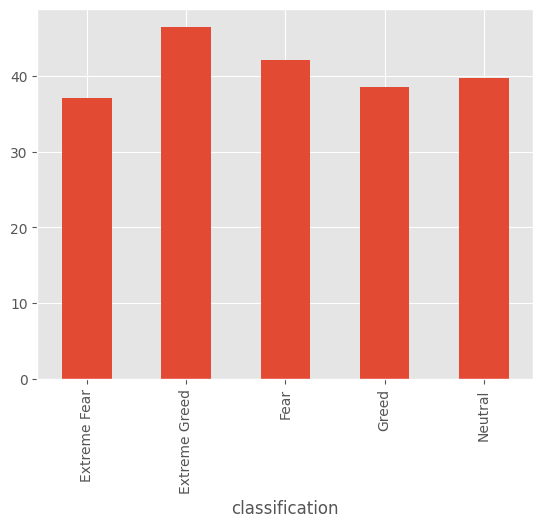

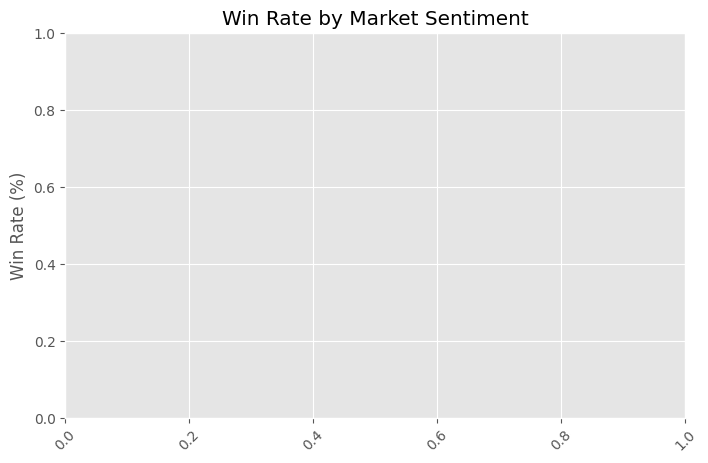

In [ ]:
#win
win_rate.plot(kind='bar')

plt.figure(figsize=(8,5))
plt.title('Win Rate by Market Sentiment')
plt.ylabel('Win Rate (%)')
plt.xticks(rotation=45)
plt.show()

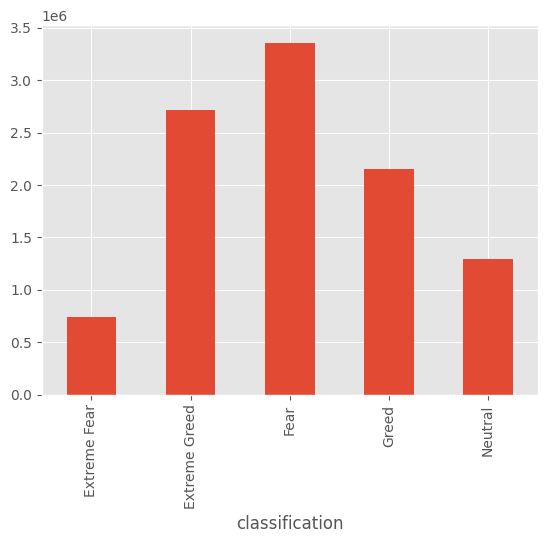

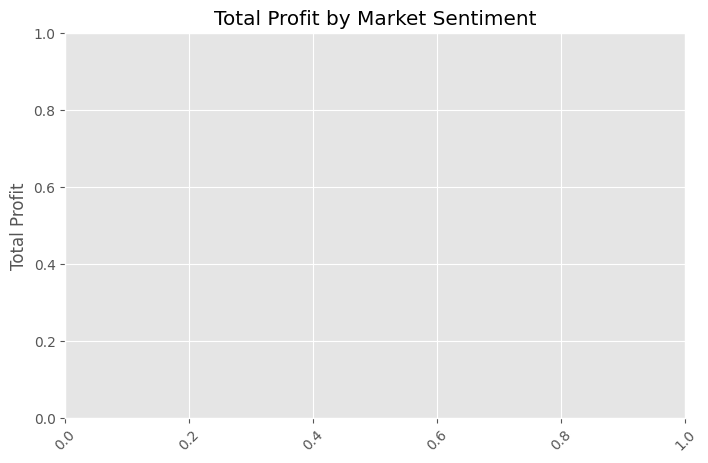

In [ ]:
# Total Profit
total_profit.plot(kind='bar')

plt.figure(figsize=(8,5))
plt.title('Total Profit by Market Sentiment')
plt.ylabel('Total Profit')
plt.xticks(rotation=45)
plt.show()

In [ ]:
summary = df.groupby('classification').agg(
    Trades=('Closed PnL', 'count'),
    Avg_PnL=('Closed PnL', 'mean'),
    Total_PnL=('Closed PnL', 'sum'),
    Win_Rate=('win', 'mean')
)

summary['Win_Rate'] = summary['Win_Rate'] * 100
summary.sort_values('Total_PnL', ascending=False)

,Trades,Avg_PnL,Total_PnL,Win_Rate
classification,,,,
Fear,61837,54.290400,3.357155e+06,42.076750
Extreme Greed,39992,67.892861,2.715171e+06,46.494299
Greed,50303,42.743559,2.150129e+06,38.482794
Neutral,37686,34.307718,1.292921e+06,39.699093
Extreme Fear,21400,34.537862,7.391102e+05,37.060748
